In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, f1_score, roc_auc_score, average_precision_score

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, precision_recall_curve, f1_score, roc_auc_score,
    precision_score, recall_score, classification_report
)

def evaluate_experiments(plots_filter, threshold_05=False, results_folder="results"):
    """
    Evaluates, prints metrics, and plots curves for selected ML experiments.
    Rankings are automatically sorted by F1-Score (descending).
    """
    
    experiments_map = {
        # ========================================================
        # --- BENCHMARK ---
        # ========================================================
        "Random Benchmark (Stratified)": "benchmark_random",

        # ========================================================
        # --- SOLO GROUPS (6) ---
        # ========================================================
        "Baseline": "only_baseline",
        "Derived Humanitarian Impact": "only_derived_humanitarian_impact",
        "Only Risk Alerts": "only_risk_alerts",
        "Only INFORM": "only_inform",
        "Only Severity": "only_severity",
        "Only Signals (CERF)": "only_signals_cerf",

        # ========================================================
        # --- COMBINED GROUPS OF 2 (15) ---
        # ========================================================
        "Baseline + Derived Humanitarian Impact": "baseline_derived_humanitarian_impact",
        "Baseline + Risk Alerts": "baseline_risk_alerts",
        "Baseline + INFORM": "baseline_inform",
        "Baseline + Severity": "baseline_severity",
        "Baseline + Signals (CERF)": "baseline_signals_cerf",
        "Derived Humanitarian Impact + Risk Alerts": "derived_humanitarian_impact_risk_alerts",
        "Derived Humanitarian Impact + INFORM": "derived_humanitarian_impact_inform",
        "Derived Humanitarian Impact + Severity": "derived_humanitarian_impact_severity",
        "Derived Humanitarian Impact + Signals (CERF)": "derived_humanitarian_impact_signals_cerf",
        "Risk Alerts + INFORM": "risk_alerts_inform",
        "Risk Alerts + Severity": "risk_alerts_severity",
        "Risk Alerts + Signals (CERF)": "risk_alerts_signals_cerf",
        "INFORM + Severity": "inform_severity",
        "INFORM + Signals (CERF)": "inform_signals_cerf",
        "Severity + Signals (CERF)": "severity_signals_cerf",

        # ========================================================
        # --- COMBINED GROUPS OF 3 (20) ---
        # ========================================================
        "Baseline + Derived Impact + Risk Alerts": "baseline_derived_impact_risk_alerts",
        "Baseline + Derived Impact + INFORM": "baseline_derived_impact_inform",
        "Baseline + Derived Impact + Severity": "baseline_derived_impact_severity",
        "Baseline + Derived Impact + Signals (CERF)": "baseline_derived_impact_signals_cerf",
        "Baseline + Risk Alerts + INFORM": "baseline_risk_alerts_inform",
        "Baseline + Risk Alerts + Severity": "baseline_risk_alerts_severity",
        "Baseline + Risk Alerts + Signals (CERF)": "baseline_risk_alerts_signals_cerf",
        "Baseline + INFORM + Severity": "baseline_inform_severity",
        "Baseline + INFORM + Signals (CERF)": "baseline_inform_signals_cerf",
        "Baseline + Severity + Signals (CERF)": "baseline_severity_signals_cerf",
        "Derived Impact + Risk Alerts + INFORM": "derived_impact_risk_alerts_inform",
        "Derived Impact + Risk Alerts + Severity": "derived_impact_risk_alerts_severity",
        "Derived Impact + Risk Alerts + Signals (CERF)": "derived_impact_risk_alerts_signals_cerf",
        "Derived Impact + INFORM + Severity": "derived_impact_inform_severity",
        "Derived Impact + INFORM + Signals (CERF)": "derived_impact_inform_signals_cerf",
        "Derived Impact + Severity + Signals (CERF)": "derived_impact_severity_signals_cerf",
        "Risk Alerts + INFORM + Severity": "risk_alerts_inform_severity",
        "Risk Alerts + INFORM + Signals (CERF)": "risk_alerts_inform_signals_cerf",
        "Risk Alerts + Severity + Signals (CERF)": "risk_alerts_severity_signals_cerf",
        "INFORM + Severity + Signals (CERF)": "inform_severity_signals_cerf",

        # ========================================================
        # --- COMBINED GROUPS OF 4 (15) ---
        # ========================================================
        "Baseline + Derived Impact + Risk Alerts + INFORM": "baseline_derived_impact_risk_alerts_inform",
        "Baseline + Derived Impact + Risk Alerts + Severity": "baseline_derived_impact_risk_alerts_severity",
        "Baseline + Derived Impact + Risk Alerts + Signals (CERF)": "baseline_derived_impact_risk_alerts_signals_cerf",
        "Baseline + Derived Impact + INFORM + Severity": "baseline_derived_impact_inform_severity",
        "Baseline + Derived Impact + INFORM + Signals (CERF)": "baseline_derived_impact_inform_signals_cerf",
        "Baseline + Derived Impact + Severity + Signals (CERF)": "baseline_derived_impact_severity_signals_cerf",
        "Baseline + Risk Alerts + INFORM + Severity": "baseline_risk_alerts_inform_severity",
        "Baseline + Risk Alerts + INFORM + Signals (CERF)": "baseline_risk_alerts_inform_signals_cerf",
        "Baseline + Risk Alerts + Severity + Signals (CERF)": "baseline_risk_alerts_severity_signals_cerf",
        "Baseline + INFORM + Severity + Signals (CERF)": "baseline_inform_severity_signals_cerf",
        "Derived Impact + Risk Alerts + INFORM + Severity": "derived_impact_risk_alerts_inform_severity",
        "Derived Impact + Risk Alerts + INFORM + Signals (CERF)": "derived_impact_risk_alerts_inform_signals_cerf",
        "Derived Impact + Risk Alerts + Severity + Signals (CERF)": "derived_impact_risk_alerts_severity_signals_cerf",
        "Derived Impact + INFORM + Severity + Signals (CERF)": "derived_impact_inform_severity_signals_cerf",
        "Risk Alerts + INFORM + Severity + Signals (CERF)": "risk_alerts_inform_severity_signals_cerf",

        # ========================================================
        # --- COMBINED GROUPS OF 5 (6) ---
        # ========================================================
        "Baseline + Derived Impact + Risk Alerts + INFORM + Severity": "baseline_derived_impact_risk_alerts_inform_severity",
        "Baseline + Derived Impact + Risk Alerts + INFORM + Signals (CERF)": "baseline_derived_impact_risk_alerts_inform_signals_cerf",
        "Baseline + Derived Impact + Risk Alerts + Severity + Signals (CERF)": "baseline_derived_impact_risk_alerts_severity_signals_cerf",
        "Baseline + Derived Impact + INFORM + Severity + Signals (CERF)": "baseline_derived_impact_inform_severity_signals_cerf",
        "Baseline + Risk Alerts + INFORM + Severity + Signals (CERF)": "baseline_risk_alerts_inform_severity_signals_cerf",
        "Derived Impact + Risk Alerts + INFORM + Severity + Signals (CERF)": "derived_impact_risk_alerts_inform_severity_signals_cerf",

        # ========================================================
        # --- ALL FEATURES (1) ---
        # ========================================================
        "ALL FEATURES (Baseline + Derived Impact + Risk Alerts + INFORM + Severity + Signals CERF)": "all_features",
    }

    comparison_results = []
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 7))

    for name, prefix in experiments_map.items():
        if name not in plots_filter:
            continue

        pred_file = os.path.join(results_folder, f"{prefix}_predictions.csv")
        feat_file = os.path.join(results_folder, f"{prefix}_feature_importance.csv")
        
        if not os.path.exists(pred_file):
            print(f"⚠️ Warning: Missing prediction file for '{name}'. Skipping...")
            continue
            
        print(f"\n" + "="*60)
        print(f"ANALYZING EXPERIMENT: {name}")
        print("="*60)
        
        df_preds = pd.read_csv(pred_file)
        all_y_true = df_preds["y_true"]
        all_y_prob = df_preds["y_prob"]

        # --- THRESHOLD STRATEGY ---
        if threshold_05:
            current_threshold = 0.5
            print("⚙️ Strategy: Using Fixed Standard Threshold (0.5)")
        else:
            # Calculate precision and recall across all possible thresholds
            precisions, recalls, thresholds_pr = precision_recall_curve(all_y_true, all_y_prob)
            
            # Compute F1 scores for each threshold, avoiding division by zero
            f1_scores = np.divide(
                2 * (precisions * recalls),
                (precisions + recalls),
                out=np.zeros_like(precisions),
                where=(precisions + recalls) != 0
            )
            
            # precision_recall_curve returns len(thresholds) = len(precisions) - 1
            # We exclude the last element of f1_scores (where recall is 0) to align the indices
            best_idx = np.argmax(f1_scores[:-1])
            current_threshold = thresholds_pr[best_idx]
            
            print(f"🎯 Strategy: Maximizing F1-Score | Optimal Threshold: {current_threshold:.3f}")

        # Convert probabilities to hard binary predictions using the chosen threshold
        all_y_pred = (all_y_prob >= current_threshold).astype(int)

        # Calculate standard metrics
        f1 = f1_score(all_y_true, all_y_pred)
        prec = precision_score(all_y_true, all_y_pred, zero_division=0)
        rec = recall_score(all_y_true, all_y_pred)
        roc_auc = roc_auc_score(all_y_true, all_y_prob)
        
        num_features = len(pd.read_csv(feat_file)) if os.path.exists(feat_file) else 0
        
        # Collect execution results
        comparison_results.append({
            'Experiment': name,
            'Opt. Threshold': round(current_threshold, 3),
            'F1-Score': round(f1, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'ROC AUC': round(roc_auc, 4),
            'Features': num_features
        })

        if os.path.exists(feat_file):
            print(f"\n--- TOP 10 PREDICTORS ({name}) ---")
            df_feat = pd.read_csv(feat_file)
            print(df_feat.head(10).to_string(index=False))
        
        print(f"\nClassification Report ({name}):")
        print(classification_report(all_y_true, all_y_pred))

        # Plot ROC Curve
        fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
        ax_roc.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
        
        # Plot Precision-Recall Curve
        prec_curve, rec_curve, _ = precision_recall_curve(all_y_true, all_y_prob)
        # Using average_precision_score just for the plot legend as it's standard practice
        from sklearn.metrics import average_precision_score
        avg_prec = average_precision_score(all_y_true, all_y_prob)
        ax_pr.plot(rec_curve, prec_curve, lw=2, label=f'{name} (AP = {avg_prec:.3f})')

    # ============================================================
    # FINAL RANKING TABLE (SORTED BY F1-SCORE DESCENDING)
    # ============================================================
    if comparison_results:
        # Higher F1-Score means a better balance between precision and recall
        df_results = pd.DataFrame(comparison_results).sort_values(by='F1-Score', ascending=False)
        print("\n" + "#"*80)
        print("       FINAL RANKING (SORTED BY F1-SCORE - HIGHER IS BETTER)")
        print("#"*80)
        print(df_results.to_string(index=False))
    else:
        print("\n❌ No experiments were successfully loaded. Plots will be empty.")
        return

    # Visualizations formatting
    ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(loc='lower right', fontsize=9)
    ax_roc.grid(alpha=0.3)

    ax_pr.set_xlim([0.0, 1.0])
    ax_pr.set_ylim([0.0, 1.05])
    ax_pr.set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.legend(loc='upper right', fontsize=9)
    ax_pr.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [3]:
models = [
    # ========================================================
    # --- BENCHMARK ---
    # ========================================================
    "Random Benchmark (Stratified)",

    # ========================================================
    # --- SOLO GROUPS (6) ---
    # ========================================================
    "Baseline",
    "Derived Humanitarian Impact",
    "Only Risk Alerts",
    "Only INFORM",
    "Only Severity",
    "Only Signals (CERF)",
    
    # ========================================================
    # --- COMBINED GROUPS OF 2 (15) ---
    # ========================================================
    "Baseline + Derived Humanitarian Impact",
    "Baseline + Risk Alerts",
    "Baseline + INFORM",
    "Baseline + Severity",
    "Baseline + Signals (CERF)",
    "Derived Humanitarian Impact + Risk Alerts",
    "Derived Humanitarian Impact + INFORM",
    "Derived Humanitarian Impact + Severity",
    "Derived Humanitarian Impact + Signals (CERF)",
    "Risk Alerts + INFORM",
    "Risk Alerts + Severity",
    "Risk Alerts + Signals (CERF)",
    "INFORM + Severity",
    "INFORM + Signals (CERF)",
    "Severity + Signals (CERF)",
    
    # ========================================================
    # --- COMBINED GROUPS OF 3 (20) ---
    # ========================================================
    "Baseline + Derived Impact + Risk Alerts",
    "Baseline + Derived Impact + INFORM",
    "Baseline + Derived Impact + Severity",
    "Baseline + Derived Impact + Signals (CERF)",
    "Baseline + Risk Alerts + INFORM",
    "Baseline + Risk Alerts + Severity",
    "Baseline + Risk Alerts + Signals (CERF)",
    "Baseline + INFORM + Severity",
    "Baseline + INFORM + Signals (CERF)",
    "Baseline + Severity + Signals (CERF)",
    "Derived Impact + Risk Alerts + INFORM",
    "Derived Impact + Risk Alerts + Severity",
    "Derived Impact + Risk Alerts + Signals (CERF)",
    "Derived Impact + INFORM + Severity",
    "Derived Impact + INFORM + Signals (CERF)",
    "Derived Impact + Severity + Signals (CERF)",
    "Risk Alerts + INFORM + Severity",
    "Risk Alerts + INFORM + Signals (CERF)",
    "Risk Alerts + Severity + Signals (CERF)",
    "INFORM + Severity + Signals (CERF)",
    
    # ========================================================
    # --- COMBINED GROUPS OF 4 (15) ---
    # ========================================================
    "Baseline + Derived Impact + Risk Alerts + INFORM",
    "Baseline + Derived Impact + Risk Alerts + Severity",
    "Baseline + Derived Impact + Risk Alerts + Signals (CERF)",
    "Baseline + Derived Impact + INFORM + Severity",
    "Baseline + Derived Impact + INFORM + Signals (CERF)",
    "Baseline + Derived Impact + Severity + Signals (CERF)",
    "Baseline + Risk Alerts + INFORM + Severity",
    "Baseline + Risk Alerts + INFORM + Signals (CERF)",
    "Baseline + Risk Alerts + Severity + Signals (CERF)",
    "Baseline + INFORM + Severity + Signals (CERF)",
    "Derived Impact + Risk Alerts + INFORM + Severity",
    "Derived Impact + Risk Alerts + INFORM + Signals (CERF)",
    "Derived Impact + Risk Alerts + Severity + Signals (CERF)",
    "Derived Impact + INFORM + Severity + Signals (CERF)",
    "Risk Alerts + INFORM + Severity + Signals (CERF)",
    
    # ========================================================
    # --- COMBINED GROUPS OF 5 (6) ---
    # ========================================================
    "Baseline + Derived Impact + Risk Alerts + INFORM + Severity",
    "Baseline + Derived Impact + Risk Alerts + INFORM + Signals (CERF)",
    "Baseline + Derived Impact + Risk Alerts + Severity + Signals (CERF)",
    "Baseline + Derived Impact + INFORM + Severity + Signals (CERF)",
    "Baseline + Risk Alerts + INFORM + Severity + Signals (CERF)",
    "Derived Impact + Risk Alerts + INFORM + Severity + Signals (CERF)",
    
    # ========================================================
    # --- ALL FEATURES (1) ---
    # ========================================================
    "ALL FEATURES (Baseline + Derived Impact + Risk Alerts + INFORM + Severity + Signals CERF)",
]


ANALYZING EXPERIMENT: Random Benchmark (Stratified)
🎯 Strategy: Maximizing F1-Score | Optimal Threshold: 0.000

Classification Report (Random Benchmark (Stratified)):
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      3984
         1.0       0.02      1.00      0.04        76

    accuracy                           0.02      4060
   macro avg       0.01      0.50      0.02      4060
weighted avg       0.00      0.02      0.00      4060


ANALYZING EXPERIMENT: Baseline
🎯 Strategy: Maximizing F1-Score | Optimal Threshold: 0.571

--- TOP 10 PREDICTORS (Baseline) ---
             feature  importance
          fatalities    0.597140
monthly_displacement    0.370454
         event_count    0.032406

Classification Report (Baseline):
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      3984
         1.0       0.21      0.33      0.26        76

    accuracy                           0.96  

/Users/gal.lagelpibuxade/Desktop/Master_thesis/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gal.lagelpibuxade/Desktop/Master_thesis/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gal.lagelpibuxade/Desktop/Master_thesis/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi


--- TOP 10 PREDICTORS (Only Risk Alerts) ---
            feature  importance
     logfat_risk_12    0.195397
      logfat_risk_3    0.190099
logfat_risk_12_lag1    0.159468
 logfat_risk_3_lag1    0.144524
            risk_12    0.076254
       risk_12_lag1    0.075956
        risk_3_lag1    0.070347
             risk_3    0.066001
          hdx_value    0.011684
         risk_gt_06    0.010271

Classification Report (Only Risk Alerts):
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98      3984
         1.0       0.16      0.34      0.22        76

    accuracy                           0.95      4060
   macro avg       0.58      0.65      0.60      4060
weighted avg       0.97      0.95      0.96      4060


ANALYZING EXPERIMENT: Only INFORM
🎯 Strategy: Maximizing F1-Score | Optimal Threshold: 0.816

--- TOP 10 PREDICTORS (Only INFORM) ---
feature  importance
     HA    0.335616
 INFORM    0.317195
     VU    0.226776
     CC    0.1204

/var/folders/n9/kv5pq1015h5cxdk8s76mbdxw0000gn/T/ipykernel_29303/1563570378.py:228: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


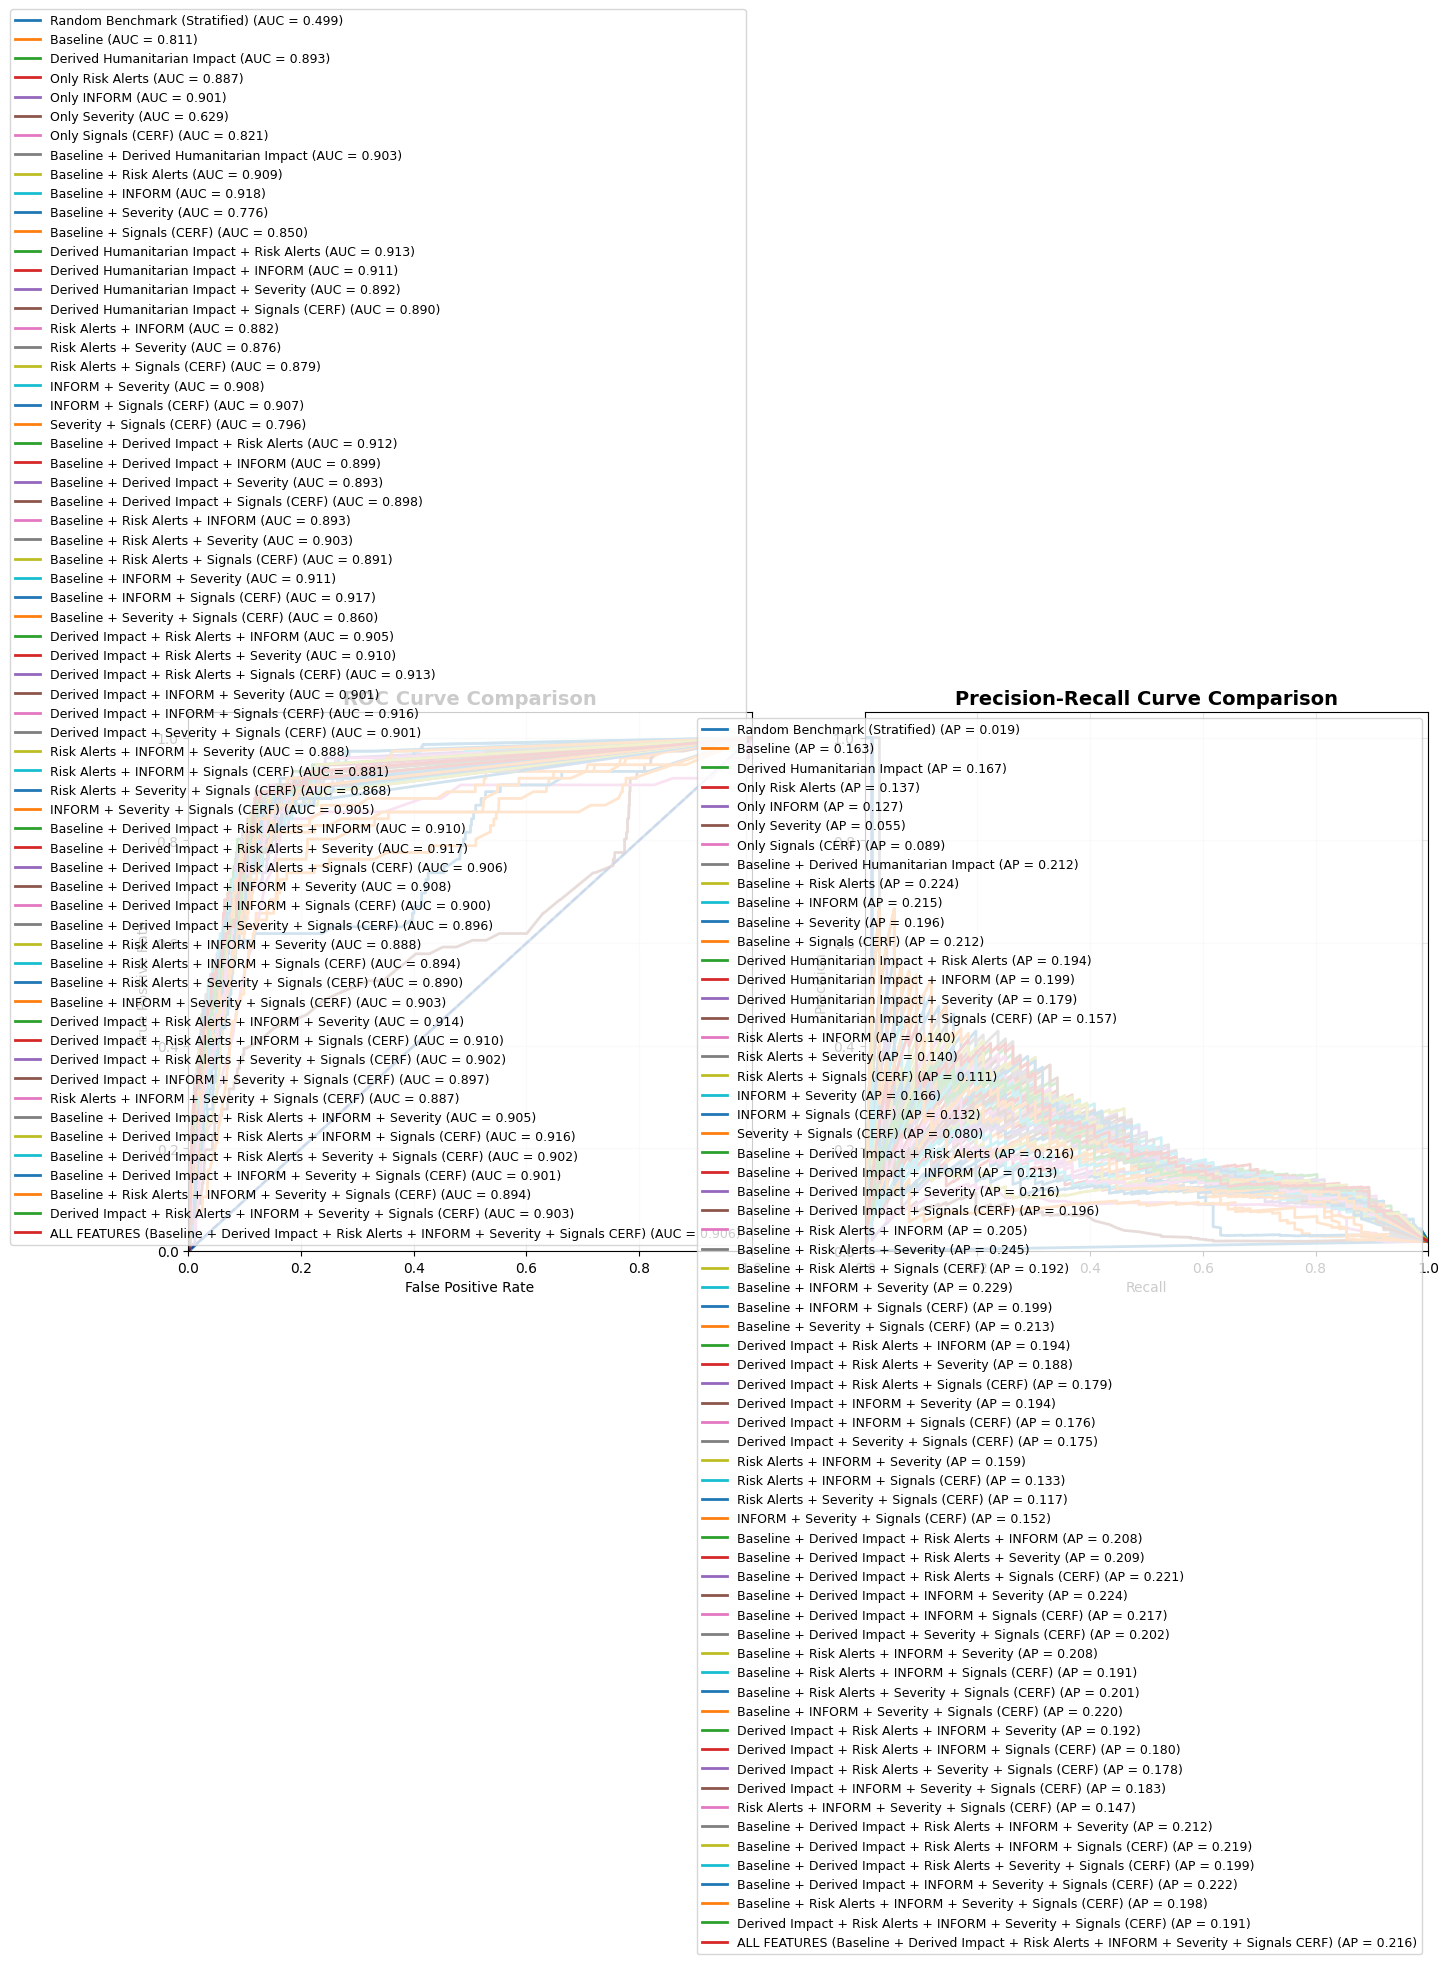

In [4]:
evaluate_experiments(plots_filter=models, threshold_05=False)